# Notebook to Explore Methods to Query MAST

## Ways to Query

There are numerous ways to query the MAST and NASAExp Datasets. They all vary in levels of access and could potentially impact the time it takes to actually download and collate data from multiple sources. The goal of this notebook is to identify the most efficient way to query these datasets and to work with this data.

| Tool                                      | Scope                                                                                                                                                                                                                                                   | Best at                                                                                                                   | Kepler/K2-specific behavior                                                                                                                                                                                                         | Main trade-off                                                                                                                     |
| ----------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **`Observations`**                        | The primary MAST interface for observational metadata and products across missions; it uses the MAST Portal API and returns Astropy `Table` objects. It is described as the recommended starting point for most users. ([astroquery.readthedocs.io][1]) | Cross-mission searches, rich metadata filters, product discovery, and downloads. ([astroquery.readthedocs.io][1])         | You can query Kepler/K2 as part of the broader archive, but it is mission-agnostic rather than Kepler/K2-specialized. ([astroquery.readthedocs.io][1])                                                                              | More flexible, but usually more manual filtering on your side. ([astroquery.readthedocs.io][1])                                    |
| **`MastMissionsClass` (“Kepler helper”)** | The mission-search class in `astroquery.mast`; astroquery’s docs separate this from the general observation search interface. ([astroquery.readthedocs.io][2])                                                                                          | Staying inside one mission’s data model and search flow. ([astroquery.readthedocs.io][2])                                 | This is the mission-specific layer you would use when your intent is “Kepler/K2 only,” rather than all of MAST. That is a mission-specific design choice, so it is narrower than `Observations`. ([astroquery.readthedocs.io][2])   | Less general than `Observations`; better for focused mission queries than archive-wide discovery. ([astroquery.readthedocs.io][2]) |
| **Lightkurve**                            | A domain-specific package for Kepler/K2/TESS time-series work. It says it uses Astroquery to search MAST and provides `search_lightcurve`, `search_targetpixelfile`, and `search_tesscut`. ([lightkurve.github.io][3])                                  | Fast light-curve and target-pixel-file workflows: search, download, plot, stitch, and filter. ([lightkurve.github.io][4]) | `search_lightcurve()` accepts an object name, **KIC or EPIC ID**, or coordinates; its `mission` filter includes **Kepler** and **K2** by default; it also supports `author`, `quarter`, and `campaign`. ([lightkurve.github.io][5]) | Best for light curves and TPFs, not for arbitrary archive products or broad metadata exploration. ([lightkurve.github.io][4])      |

[1]: https://astroquery.readthedocs.io/en/latest/mast/mast_obsquery.html "Observation Queries — astroquery v0.1.dev269+gf7db6753c"
[2]: https://astroquery.readthedocs.io/en/stable/mast/mast.html "MAST Queries (astroquery.mast) — astroquery v0.4.11"
[3]: https://lightkurve.github.io/lightkurve/tutorials/1-getting-started/searching-for-data-products.html "Searching & downloading Kepler, K2, and TESS data — Lightkurve "
[4]: https://lightkurve.github.io/lightkurve/reference/search.html "Downloading data — Lightkurve "
[5]: https://lightkurve.github.io/lightkurve/reference/api/lightkurve.search_lightcurve.html "lightkurve.search_lightcurve — Lightkurve "


## Approach

1. Load the Kepler Villanova Eclipsing Binaries Catalog (.csv) file
2. Sample a record (by KIC/KID)
3. Use different approaches to load it's data and time doing it

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lightkurve as lk
from astroquery.mast import Mast, Observations
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from time import perf_counter

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Load Data from KVEBC

In [2]:
keb = pd.read_csv(r'../assets/data/kepler-eclipsing-binary-catalog.csv')
keb = keb.drop(columns='Unnamed: 11')
keb.columns


Index(['KIC', 'period', 'period_err', 'bjd0', 'bjd0_err', 'morph', 'GLon',
       'GLat', 'kmag', 'Teff', 'SC'],
      dtype='str')

In [3]:
keb.head(20)


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC
0,3863594,0.053268,0.000000e+00,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False
1,10417986,0.073731,0.000000e+00,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True
2,8912468,0.094838,0.000000e+00,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False
3,8758716,0.107205,0.000000e+00,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False
4,10855535,0.112782,0.000000e+00,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False
5,9472174,0.125765,1.000000e-07,54953.643178,0.018318,0.78,79.0187,11.6745,12.264,10645.0,True
6,9612468,0.133471,1.000000e-07,54953.603803,0.007796,0.99,81.0112,8.5285,11.531,7202.0,False
7,6613627,0.150800,1.000000e-07,55115.344848,0.008552,0.98,75.1606,10.2517,12.548,7090.0,False
8,5302006,0.151171,1.000000e-07,54980.509040,0.007895,0.97,75.3495,6.6449,15.050,6536.0,False
9,9898401,0.152774,1.000000e-07,54964.733972,0.008810,0.99,79.6654,11.8375,12.073,7376.0,False


In [4]:
keb.shape


(2920, 11)

Randomizing the index that we sample from KEB. 

In [5]:
sampleIndex = np.random.randint(0, len(keb))
sampleKIC = int(keb.loc[sampleIndex]['KIC'])

print(f"Index: {sampleIndex} | Sample KIC: {sampleKIC}")


Index: 1381 | Sample KIC: 8189196


Turn it into a function. *We looooooveeeeee our functions :)*

In [6]:
def sampleRandomKEB():
    sampleIndex = np.random.randint(0, len(keb))
    sampleKIC = int(keb.loc[sampleIndex]['KIC'])

    return sampleKIC


## Fetching using `Lightkurve`

Getting a single quarter's LC.

In [7]:
regularLightCurve = lk.search_lightcurve(f"KIC {sampleKIC}", mission="Kepler").download()
regularLightCurve


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 18 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
120.53849905890092,1.6798447e+05,1.1532171e+01,0,3.466389e-04,709.17426,253.27865,568,1.5995795e+05,1.1274754e+01,2.7678518e+03,7.1564686e-01,1.6798447e+05,1.1532171e+01,0,709.23869,4.8195110e-05,253.21482,4.7470221e-05,709.17426,8.2667648e-05,253.27865,8.2933089e-05,-1.3091456e-03,8.1210351e-04
120.55893355585431,1.6809142e+05,1.1666335e+01,10000000,3.475359e-04,709.17422,253.27871,569,1.6005489e+05,1.1277667e+01,2.7699778e+03,7.1559983e-01,1.6809142e+05,1.1666335e+01,10000000,709.23853,4.8168131e-05,253.21473,4.7452115e-05,709.17422,8.2628198e-05,253.27871,8.2903316e-05,-1.6064077e-03,6.5085047e-04
120.57936795286514,1.6820650e+05,1.1691914e+01,0,3.484329e-04,709.17450,253.27828,570,1.6016836e+05,1.1280576e+01,2.7683413e+03,7.1538371e-01,1.6820650e+05,1.1691914e+01,0,709.23882,4.8174352e-05,253.21452,4.7455065e-05,709.17450,8.2574057e-05,253.27828,8.2832223e-05,-1.2960917e-03,3.8784626e-04
120.59980254989932,1.6835520e+05,1.1689039e+01,0,3.493299e-04,709.17426,253.27755,571,1.6031369e+05,1.1286112e+01,2.7686465e+03,7.1576309e-01,1.6835520e+05,1.1689039e+01,0,709.23839,4.8123260e-05,253.21381,4.7499710e-05,709.17426,8.2518716e-05,253.27755,8.2807812e-05,-1.7025601e-03,-3.4289312e-04
120.62023704696912,1.6846288e+05,1.1699633e+01,0,3.502270e-04,709.17461,253.27746,572,1.6041692e+05,1.1289040e+01,2.7678105e+03,7.1556628e-01,1.6846288e+05,1.1699633e+01,0,709.23870,4.8128411e-05,253.21358,4.7506725e-05,709.17461,8.2475999e-05,253.27746,8.2769693e-05,-1.3029886e-03,-5.5842643e-04
120.64067144409637,1.6863017e+05,1.1707687e+01,0,3.511241e-04,709.17476,253.27697,573,1.6057580e+05,1.1293243e+01,2.7678286e+03,7.1585822e-01,1.6863017e+05,1.1707687e+01,0,709.23873,4.8098507e-05,253.21314,4.7500413e-05,709.17476,8.2399216e-05,253.27697,8.2699764e-05,-1.3096333e-03,-1.0416108e-03
120.6611059412462,1.6876378e+05,1.1708464e+01,0,3.520212e-04,709.17472,253.27699,574,1.6070027e+05,1.1296783e+01,2.7702600e+03,7.1559811e-01,1.6876378e+05,1.1708464e+01,0,709.23868,4.8083417e-05,253.21310,4.7494872e-05,709.17472,8.2353479e-05,253.27699,8.2652536e-05,-1.3743880e-03,-1.0922132e-03
120.68154053846229,1.6887666e+05,1.1709529e+01,0,3.529185e-04,709.17491,253.27676,575,1.6080600e+05,1.1299554e+01,2.7691440e+03,7.1488434e-01,1.6887666e+05,1.1709529e+01,0,709.23884,4.8072372e-05,253.21306,4.7473295e-05,709.17491,8.2305858e-05,253.27676,8.2605206e-05,-1.2458356e-03,-1.1135925e-03


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

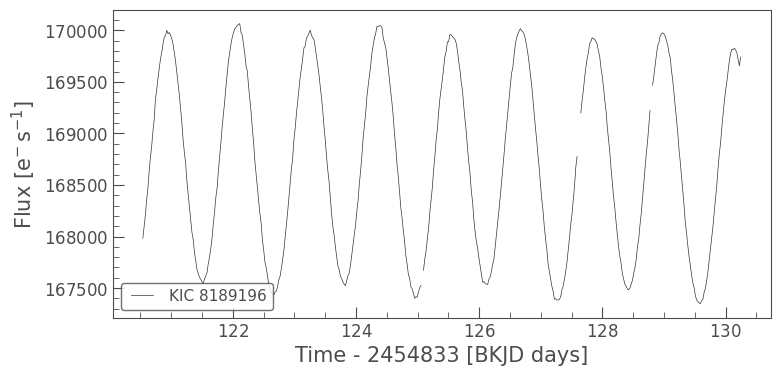

In [8]:
regularLightCurve.plot()


In [17]:
search = lk.search_lightcurve(
    f"{sampleKIC}",
    mission="Kepler",
    author="Kepler",
    cadence="long"
)

search


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 00,2009,Kepler,1800,kplr008553907,0.0
1,Kepler Quarter 01,2009,Kepler,1800,kplr008553907,0.0
2,Kepler Quarter 02,2009,Kepler,1800,kplr008553907,0.0
3,Kepler Quarter 03,2009,Kepler,1800,kplr008553907,0.0
4,Kepler Quarter 04,2010,Kepler,1800,kplr008553907,0.0
5,Kepler Quarter 05,2010,Kepler,1800,kplr008553907,0.0
6,Kepler Quarter 06,2010,Kepler,1800,kplr008553907,0.0
7,Kepler Quarter 07,2010,Kepler,1800,kplr008553907,0.0
8,Kepler Quarter 10,2011,Kepler,1800,kplr008553907,0.0


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

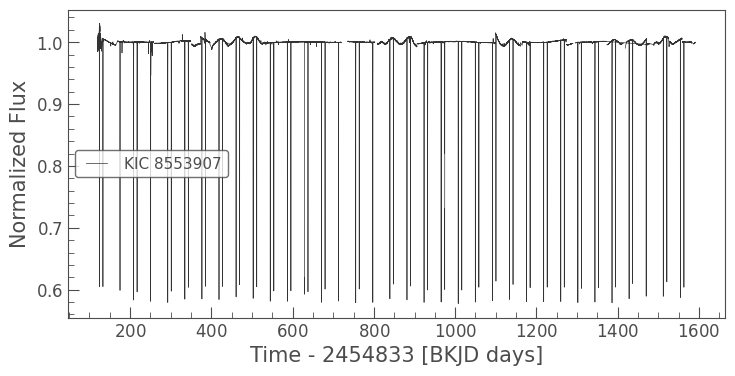

In [18]:
stitchedLightCurve = search.download_all().stitch()
stitchedLightCurve.plot()


Create a function to fetch a light curve and stitch it.

In [19]:
def fetchLightCurveCollectionKepler(KIC):
    search = lk.search_lightcurve(
        f"KIC {KIC}",
        mission="Kepler",
        author="Kepler",
        cadence="long"
    )

    return search.download_all().stitch()


In [20]:
start = perf_counter()
sampleKIC = sampleRandomKEB()
lc = fetchLightCurveCollectionKepler(sampleKIC)
end = perf_counter()

len(lc)


65031

In [21]:
print(f"Time Elapsed: {end - start : .4f}s")


Time Elapsed:  17.0182s


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

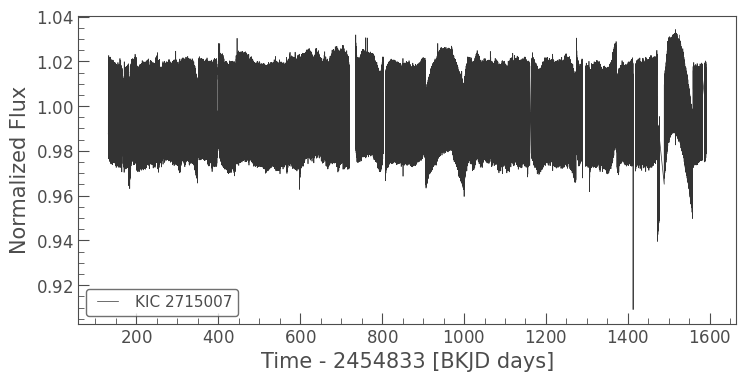

In [22]:
lc.plot()


Looking up, fetching and stitching LC data using `lightkurve` takes around 10-12s for each record.

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

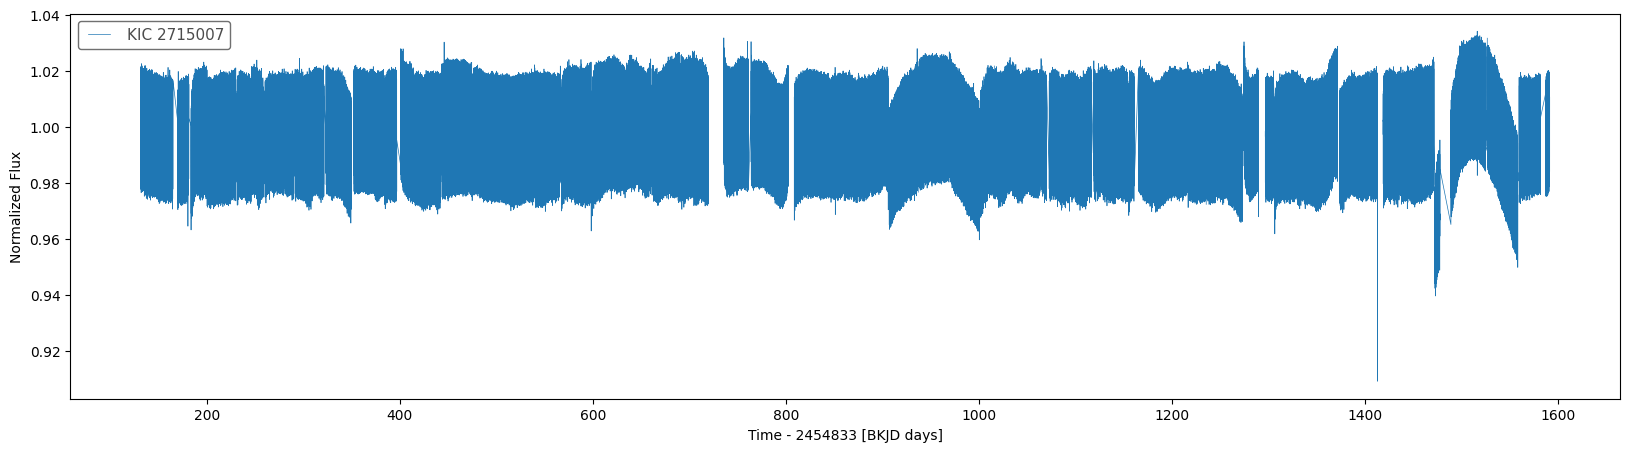

In [23]:
fig, ax = plt.subplots(figsize=(20,5))

lc.normalize().plot(ax=ax)


To apply phase-folding to the LC, fetch `koi_period` (orbital period in days) and `koi_time0bk` (transit midpoint epoch, in BKJD) from NASAExpArch and pass into `lc.fold()`.

In [24]:
# folded = lc.fold(period=period, epoch_time=t0)
# folded.plot()


## Fetching data with `MAST.Observations`